c:\Program Files\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Program Files\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG11_Weights.IMAGENET1K_V1`. You can also use `weights=VGG11_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (11): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): ReLU(inplace=True)
    (13): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (14): ReLU(inplace=True)
    (15): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
 

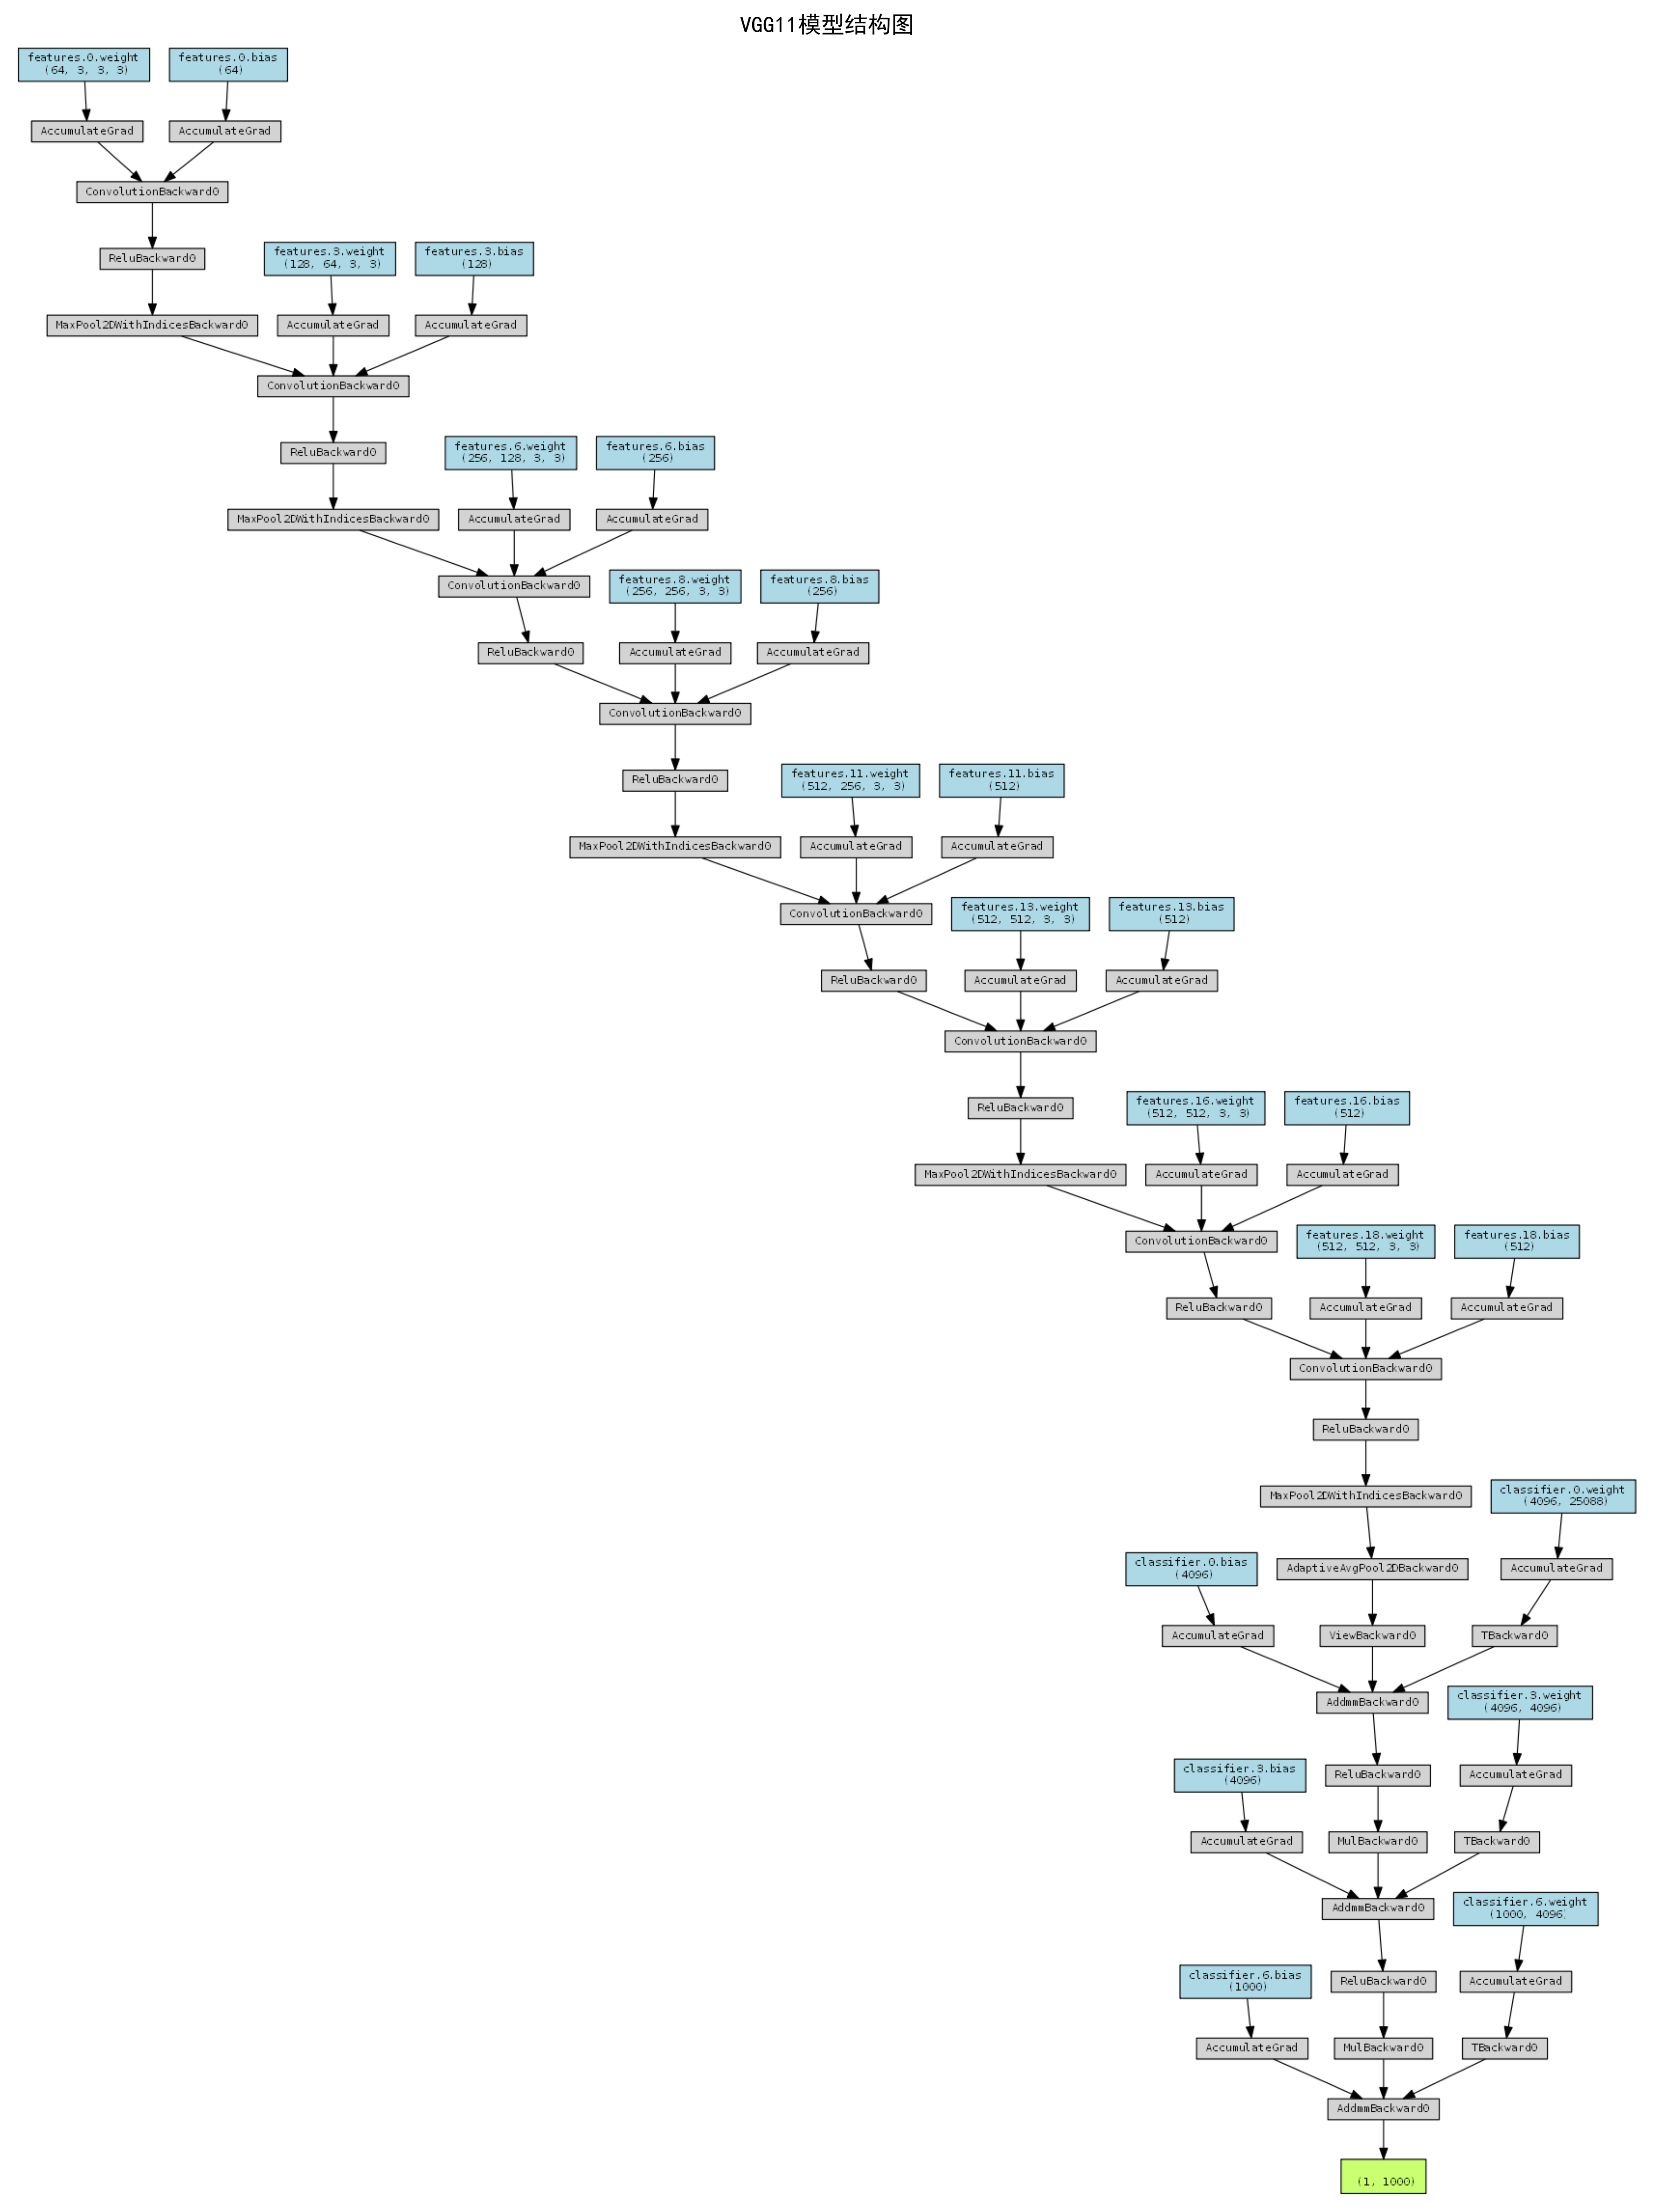

VGG11模型的详细参数信息:
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 224, 224]           1,792
              ReLU-2         [-1, 64, 224, 224]               0
         MaxPool2d-3         [-1, 64, 112, 112]               0
            Conv2d-4        [-1, 128, 112, 112]          73,856
              ReLU-5        [-1, 128, 112, 112]               0
         MaxPool2d-6          [-1, 128, 56, 56]               0
            Conv2d-7          [-1, 256, 56, 56]         295,168
              ReLU-8          [-1, 256, 56, 56]               0
            Conv2d-9          [-1, 256, 56, 56]         590,080
             ReLU-10          [-1, 256, 56, 56]               0
        MaxPool2d-11          [-1, 256, 28, 28]               0
           Conv2d-12          [-1, 512, 28, 28]       1,180,160
             ReLU-13          [-1, 512, 28, 28]               0
           Conv2d-14   

In [7]:
import torchvision.models as models

import torchvision.models as models

# 加载预训练的VGG11模型
vgg11 = models.vgg11(pretrained=True)

# 打印模型结构
print(vgg11)
total_params = sum(p.numel() for p in vgg11.parameters())
print(f"vgg11模型的总参数量: {total_params:,}")

# 导入可视化模型结构所需的库
import torch
from torchviz import make_dot
from torch.autograd import Variable
import matplotlib.pyplot as plt
import io
from PIL import Image
from torchsummary import summary
import numpy as np

# 创建一个示例输入
x = Variable(torch.randn(1, 3, 224, 224))

# 获取模型输出
y = vgg11(x)
# 设置matplotlib支持中文字体
from matplotlib import rcParams
rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']  # 增加一些常见的中文字体
rcParams['axes.unicode_minus'] = False  # 正确显示负号

# 使用make_dot生成计算图
dot = make_dot(y, params=dict(vgg11.named_parameters()))

# 保存计算图为图片
dot.format = 'png'
dot.render("vgg11_structure", cleanup=True)

# 显示模型结构图
try:
    img = Image.open("vgg11_structure.png")
    plt.figure(figsize=(15, 20),dpi=300)
    plt.imshow(np.array(img))
    plt.axis('off')
    plt.title("VGG11模型结构图")
    plt.show()
except:
    print("无法显示图像，请检查torchviz是否正确安装")

# 使用torchsummary打印模型的详细参数信息
print("VGG11模型的详细参数信息:")
summary(vgg11, (3, 224, 224), device="cpu")


In [11]:
import torch
from torch import nn

# 创建输入张量，假设batch_size=1, channels=3, 高=32, 宽=32
x = torch.randn(1, 3, 32, 32)

# 定义一个单独的卷积层，kernel_size=3, stride=2, padding='same'
conv = nn.Conv2d(in_channels=3, out_channels=3, kernel_size=3, stride=2, padding=0)

# 前向传播运算
y = conv(x)

print(f"输入形状: {x.shape}")
print(f"输出形状: {y.shape}")


输入形状: torch.Size([1, 3, 32, 32])
输出形状: torch.Size([1, 3, 15, 15])
